In [2]:
import os
import matplotlib.pyplot as plt
from src.datasets.mos2_sr import MOS2SRDataset, MOS2_SAPPHIRE_DIR

dataset = MOS2SRDataset(upsample_factor=4, split="val")

In [3]:
item = dataset[0]

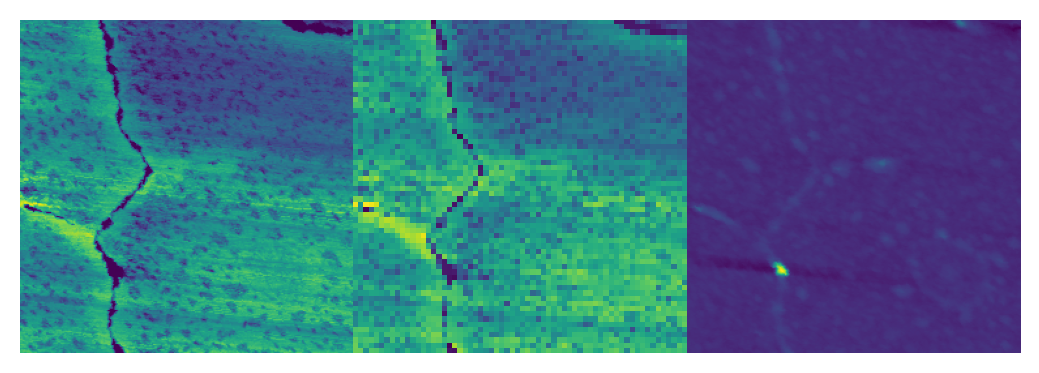

In [4]:
y = item["y"]
y_sparse = item['y_sparse']
X = item["X"]

fig, axes = plt.subplots(1, 3, figsize=(5, 15), dpi=200)

axes[0].imshow(y)
axes[0].axis('off')

axes[1].imshow(y_sparse)
axes[1].axis('off')

axes[2].axis('off')
axes[2].imshow(X)

plt.subplots_adjust(wspace=0, hspace=0)
plt.tight_layout(pad=0)
plt.show()

In [5]:
import torch
from src.models.our_method.swin_cafm import SwinCAFM
from src.models.prev_methods.gpr import GPR
from src.models.prev_methods.rnan import RNAN

our_best_fp = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/foundation-models/3. combined/4x/2025-03-03_10-59-32_DS={all}-[X|y]-BS=32-opt=Adam-lr=1e-5/DS={all}-[X|y]-BS=32-opt=Adam-lr=1e-5_best.pth"
rnan_best_fp = "/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/__exps__/ablations/rnan/2025-03-11_09-57-47_4x-DS={all}/4x-DS={all}_best.pth"

our_best: SwinCAFM = torch.load(our_best_fp)
rnan: RNAN = torch.load(rnan_best_fp)
gpr = GPR(sr=4)

/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/mufan/miniforge3/envs/control/lib/python3.8/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/tmp/ipykernel_2611258/3691961023.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `we

In [44]:
del gpr
gpr = GPR(sr=4)

In [19]:
y = item["X"]
y_sparse = item["X_sparse"]
our_pred = our_best(y_sparse.unsqueeze(0).cuda().float()); our_pred.shape

torch.Size([1, 256, 256])

In [20]:
our_pred = our_pred.squeeze(0)

In [46]:
gpr_pred = gpr.__call__(y_sparse.unsqueeze(0))

In [47]:
gpr_pred = gpr_pred.squeeze(0)

In [23]:
rnan_input = y_sparse.clone().cuda().float().unsqueeze(0).unsqueeze(0)
rnan_pred = rnan(rnan_input)
rnan_pred = rnan_pred.squeeze(1)

In [24]:
rnan_pred = rnan_pred.squeeze(0)

In [53]:
y_unnormed = item['y_unnorm']

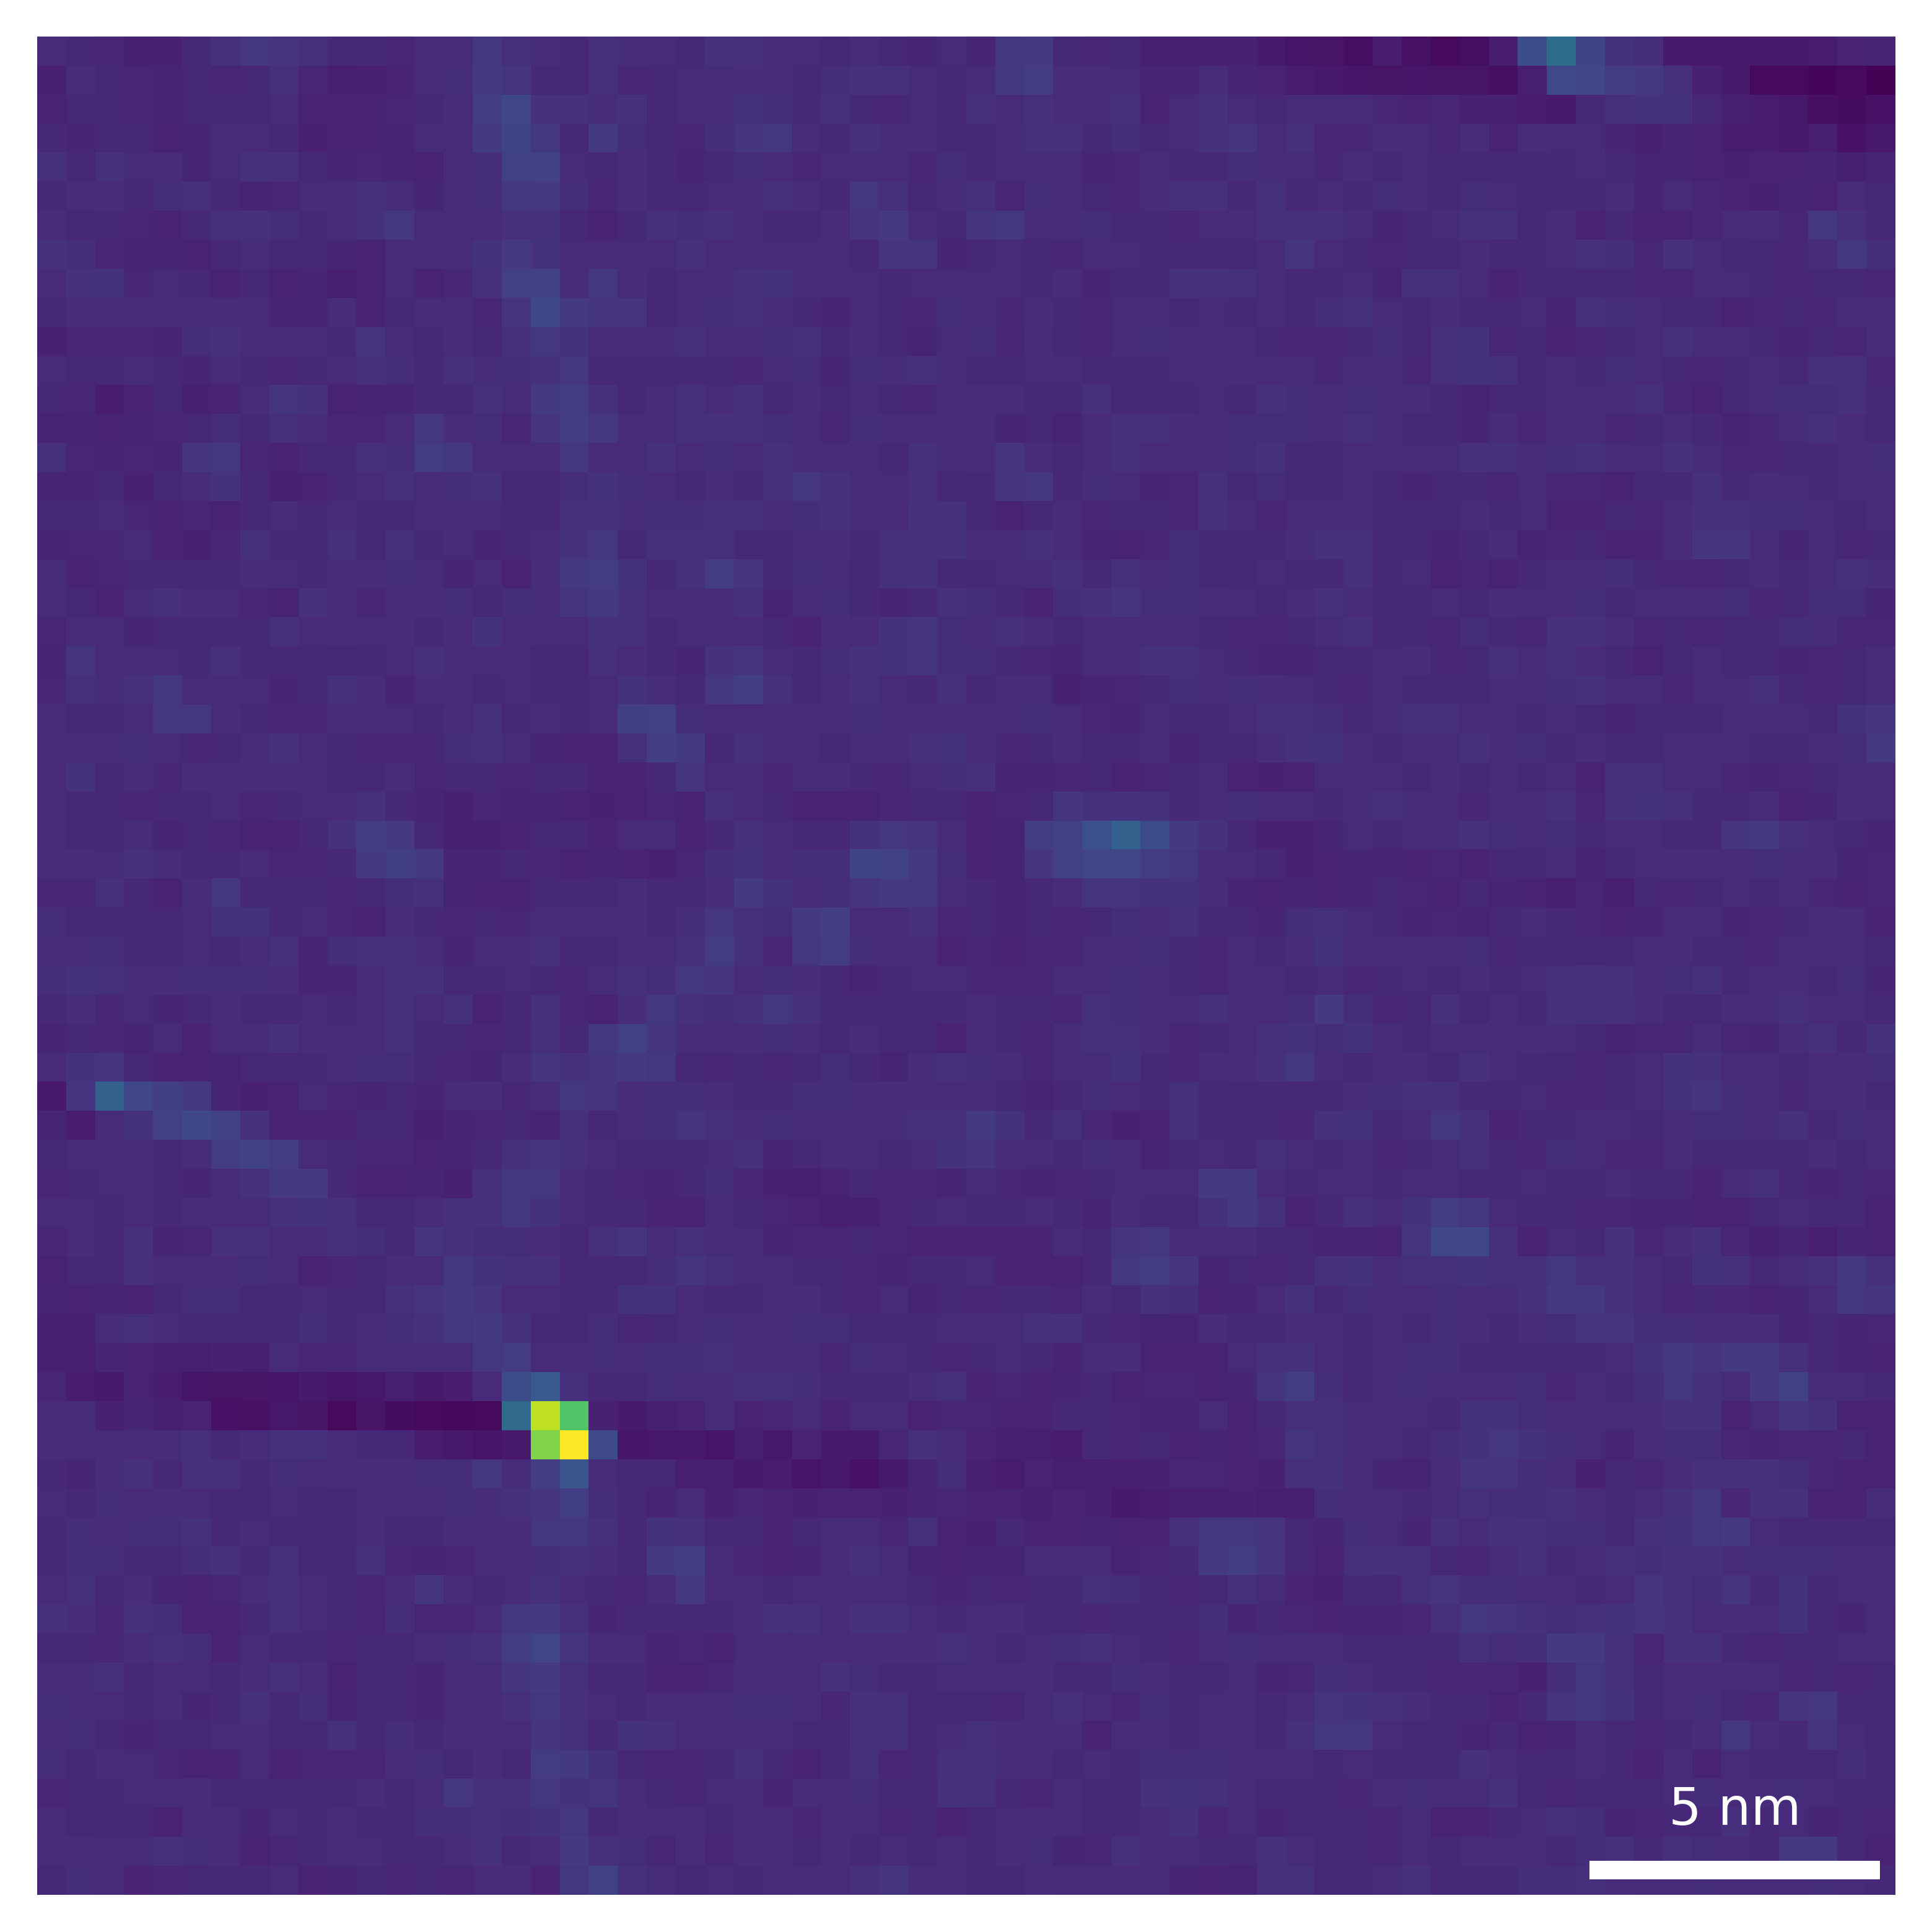

In [63]:
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar

# Convert pixel size from nm to micrometers (e.g., 0.5 nm = 0.0005 µm)
pixel_size_nm = 0.5  # nm per pixel (replace with your actual value)
pixel_size_um = pixel_size_nm / 1000  # µm per pixel

fig, ax = plt.subplots(figsize=(5, 5), dpi=600)

# Plot your image
image = y_sparse.squeeze(0).detach().cpu()
ax.imshow(image)  # specify cmap='gray' if desired
ax.axis('off')

# Add scalebar in micrometers
scalebar = ScaleBar(pixel_size_um, units="µm", length_fraction=0.25, location='lower right',
                    box_alpha=0, color='white', scale_loc='top')
ax.add_artist(scalebar)

# Adjust layout
plt.subplots_adjust(wspace=0, hspace=0)
plt.tight_layout(pad=0)

# Save figure
fig_name = "rnan_pred"
src_dir = f"/playpen/mufan/levi/tianlong-chen-lab/material-super-resolution/figures/current-topo-two-row-grid-ii/X/{fig_name}.png"
plt.savefig(src_dir, bbox_inches='tight', pad_inches=0)

plt.show()

In [37]:
X_unnormed = item['X_unnorm']

In [ ]:
y_unnormed

tensor(0.7886)

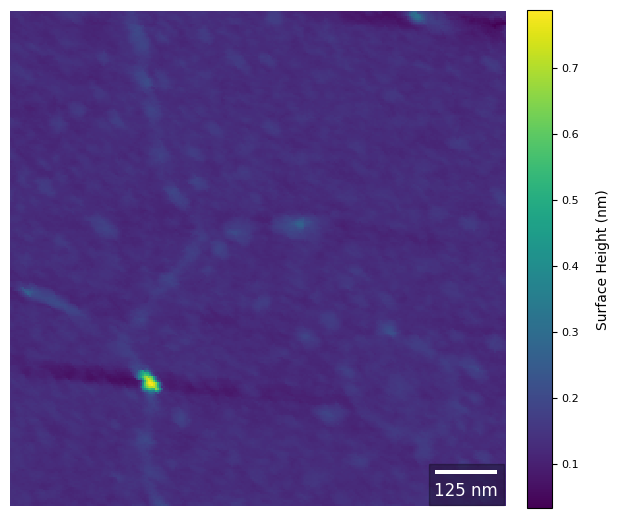

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_scalebar.scalebar import ScaleBar
import numpy as np

# image_data = y_hat_bicubic.detach().cpu().squeeze(0)

fig, ax = plt.subplots(figsize=(6, 6), dpi=100)
img = ax.imshow(y, cmap='viridis', interpolation='nearest')
ax.axis('off')

pixel_size_um = 2.0 / 512
scalebar = ScaleBar(pixel_size_um, "um",
                    location='lower right',  # position it nicely
                    color='white',
                    box_color='black',
                    box_alpha=0.3,
                    font_properties={'size': 12},
                    length_fraction=0.15,  # custom length relative to axes
                    frameon=True,          # adds a nice box around the scale bar
                    pad=0.4)
ax.add_artist(scalebar)

cbar = plt.colorbar(img, fraction=0.046, pad=0.04)
cbar.set_label('Surface Height (nm)', fontsize=10, labelpad=12)
cbar.ax.tick_params(labelsize=8)

# out_dir = "figures/current-topo-two-row-grid-ii"
plt.tight_layout(pad=0.01)
# plt.savefig(f'{out_dir}/c_bicubic.png', dpi=300, bbox_inches='tight')
plt.show()